# Research Objective

This experiment recovers Black–Scholes implied volatilities from SPY option quotes and investigates whether a constant volatility can explain prices across strikes and expirations.

## Data and modelling assumptions

This experiment uses a fixed snapshot of SPY option quotes collected on **18 July 2026 at 06:06 UTC**, when the recorded underlying spot price was approximately **$743.29**. Three expirations were selected to represent short-, medium- and longer-dated contracts, with approximately **27, 90 and 181 days to expiry**. Using a fixed snapshot ensures that the results remain reproducible even as market prices and available contracts change.

The following assumptions are applied throughout the analysis:

- **Option price:** Each contract is represented by the midpoint of its quoted bid and ask:

  $$
  V_{\text{mid}}=\frac{V_{\text{bid}}+V_{\text{ask}}}{2}.
  $$

  The midpoint provides a more stable estimate of the current market value than the last traded price, although it may not represent an immediately executable price.

- **Time to maturity:** Maturity is calculated using an ACT/365 convention:

  $$
  T=\frac{\text{calendar days to expiry}}{365}.
  $$

- **Risk-free rate:** A flat, continuously compounded annual risk-free rate of **4.0%** is applied to all expirations.

- **Dividend yield:** A flat, continuously compounded annual dividend yield of **1.2%** is assumed for SPY.

- **Pricing model:** Quotes are calibrated using the Black–Scholes–Merton model for European options with a continuous dividend yield. Implied volatility is defined as the volatility value that causes the model price to equal the observed bid–ask midpoint.

- **Exercise style:** SPY options may be exercised before expiration, while the implemented model assumes European exercise. The resulting implied volatilities should therefore be interpreted as European-model approximations, particularly for contracts where early exercise may be valuable.

- **Forward price:** Forward moneyness is calculated using

  $$
  F_0(T)=S_0e^{(r-q)T},
  $$

  and contracts are compared using log-forward moneyness:

  $$
  k=\log\left(\frac{K}{F_0(T)}\right).
  $$

  A value of $k=0$ represents an approximately at-the-money-forward option.

- **Quote filtering:** Before calibration, contracts are required to have:
  - a positive bid;
  - an ask greater than the bid;
  - between 14 and 365 days to expiry;
  - strike moneyness between 80% and 120% of spot;
  - a relative bid–ask spread no greater than 30%;
  - open interest of at least 10 contracts.

These filters reduce the influence of stale, one-sided and illiquid quotes. They retained **378 of 892 contracts**, corresponding to a retention rate of approximately **42.4%**.

The analysis also assumes that the option quotes and underlying spot price are sufficiently close in observation time. In practice, asynchronous updates, discrete dividends, transaction costs and differences in vendor methodology may contribute to discrepancies between the calculated implied volatilities and the values supplied by Yahoo Finance.



## Load market snapshot

The analysis uses a fixed market snapshot so that results remain reproducible. A separate script is provided to download a new snapshot.

In [1]:
from pathlib import Path

import pandas as pd

from derivative_pricing.calibration.option_chain import (
    filter_option_chain,
    prepare_option_chain,
)

SNAPSHOT_PATH = Path(
    "../data/raw/options/SPY_20260718T060648Z.csv"
)
DIVIDEND_YIELD = 0.012

raw_quotes = pd.read_csv(SNAPSHOT_PATH)

print(raw_quotes[
    [
        "symbol",
        "spot",
        "fetched_at_utc",
        "expiration",
    ]
].head())

print(f"Raw contracts: {len(raw_quotes):,}")
print(f"Spot: {raw_quotes['spot'].iloc[0]:.2f}")
print(
    f"Expirations: "
    f"{raw_quotes['expiration'].nunique()}"
)


  symbol        spot                    fetched_at_utc  expiration
0    SPY  743.289978  2026-07-18T06:06:48.276117+00:00  2026-08-14
1    SPY  743.289978  2026-07-18T06:06:48.276117+00:00  2026-08-14
2    SPY  743.289978  2026-07-18T06:06:48.276117+00:00  2026-08-14
3    SPY  743.289978  2026-07-18T06:06:48.276117+00:00  2026-08-14
4    SPY  743.289978  2026-07-18T06:06:48.276117+00:00  2026-08-14
Raw contracts: 892
Spot: 743.29
Expirations: 3


In [2]:

prepared_quotes = prepare_option_chain(raw_quotes)
filtered_quotes = filter_option_chain(prepared_quotes)

assert prepared_quotes["maturity"].gt(0).all()
assert prepared_quotes["spot"].gt(0).all()
assert prepared_quotes["strike"].gt(0).all()

assert not filtered_quotes.empty
assert filtered_quotes["expiration"].nunique() >= 3

expiration_summary = (
    prepared_quotes
    .groupby("expiration", as_index=False)
    .agg(
        days_to_expiry=("days_to_expiry", "first"),
        contracts=("strike", "size"),
        minimum_strike=("strike", "min"),
        maximum_strike=("strike", "max"),
    )
    .sort_values("days_to_expiry")
)

print("Expiration Summary:")
print(expiration_summary)
print()
print("Retained calls and puts:")
print(filtered_quotes.groupby(
    ["expiration", "option_type"]
).size().unstack(fill_value=0))


Expiration Summary:
  expiration  days_to_expiry  contracts  minimum_strike  maximum_strike
0 2026-08-14              27        257           500.0           900.0
1 2026-10-16              90        224           300.0          1000.0
2 2027-01-15             181        411            50.0          1480.0

Retained calls and puts:
option_type  call  put
expiration            
2026-08-14     68  105
2026-10-16     57   42
2027-01-15     60   46


In [3]:
filter_funnel = []

current = prepared_quotes.copy()

filter_funnel.append(
    {
        "stage": "Raw prepared quotes",
        "contracts": len(current),
    }
)

current = current[
    (current["bid"] > 0)
    & (current["ask"] > current["bid"])
]
filter_funnel.append(
    {
        "stage": "Valid two-sided market",
        "contracts": len(current),
    }
)

current = current[
    current["days_to_expiry"].between(14, 365)
]
filter_funnel.append(
    {
        "stage": "14–365 days to expiry",
        "contracts": len(current),
    }
)

current = current[
    current["spot_moneyness"].between(0.8, 1.2)
]
filter_funnel.append(
    {
        "stage": "80–120% spot moneyness",
        "contracts": len(current),
    }
)

current = current[
    (current["relative_spread"] <= 0.30)
    & (current["openInterest"].fillna(0) >= 10)
]
filter_funnel.append(
    {
        "stage": "Liquidity filters",
        "contracts": len(current),
    }
)

filter_funnel_df = pd.DataFrame(filter_funnel)
print(filter_funnel_df)

filtered_quotes = filter_option_chain(
    prepared_quotes
)

assert len(filtered_quotes) == len(current)

                    stage  contracts
0     Raw prepared quotes        892
1  Valid two-sided market        853
2   14–365 days to expiry        853
3  80–120% spot moneyness        459
4       Liquidity filters        378


In [4]:
from derivative_pricing.calibration.option_chain import calibrate_option_chain

RISK_FREE_RATE = 0.04
DIVIDEND_YIELD = 0.012

calibrated_quotes = calibrate_option_chain(
    quotes=filtered_quotes,
    dividend_yield=DIVIDEND_YIELD,
    risk_free_rate=RISK_FREE_RATE,
)

# Implied-volatility calibration

In [5]:
calibration_summary = pd.DataFrame(
    {
        "metric": [
            "Quotes submitted",
            "Successful calibrations",
            "Failed calibrations",
            "Success rate",
        ],
        "value": [
            len(calibrated_quotes),
            calibrated_quotes["iv_converged"].sum(),
            (~calibrated_quotes["iv_converged"]).sum(),
            calibrated_quotes["iv_converged"].mean(),
        ],
    }
)

calibration_summary

,metric,value
0,Quotes submitted,378.0
1,Successful calibrations,378.0
2,Failed calibrations,0.0
3,Success rate,1.0


## Failure summary

In [6]:
failed_quotes = calibrated_quotes.loc[
    ~calibrated_quotes["iv_converged"]
]

if failed_quotes.empty:
    print("All submitted quotes calibrated successfully.")
else:
    display(
        failed_quotes["iv_failure_reason"]
        .value_counts()
        .rename_axis("failure_reason")
        .reset_index(name="quotes")
    )

All submitted quotes calibrated successfully.


In [7]:
successful_quotes = calibrated_quotes.loc[
    calibrated_quotes["iv_converged"]
].copy()

successful_quotes["model_implied_volatility"] = (
    successful_quotes["model_implied_volatility"].astype(float)
)

# Solver validation against vendor estimates

In [8]:
successful_quotes["vendor_iv_difference"] = (
    successful_quotes["model_implied_volatility"]
    - successful_quotes["impliedVolatility"]
)

successful_quotes[
    [
        "model_implied_volatility",
        "impliedVolatility",
        "vendor_iv_difference",
    ]
].describe()

,model_implied_volatility,impliedVolatility,vendor_iv_difference
count,378.000000,378.000000,378.000000
mean,0.185832,0.189335,-0.003504
std,0.057066,0.065395,0.023512
min,0.110353,0.106576,-0.083215
25%,0.140663,0.138108,-0.011336
50%,0.171042,0.168534,-0.000985
75%,0.221097,0.224873,0.010306
max,0.397703,0.387946,0.061786


In [9]:
import numpy as np


vendor_comparison = pd.Series(
    {
        "mean_difference": (
            successful_quotes["vendor_iv_difference"].mean()
        ),
        "median_absolute_difference": (
            successful_quotes["vendor_iv_difference"].abs().median()
        ),
        "root_mean_squared_difference": np.sqrt(
            np.mean(
                successful_quotes["vendor_iv_difference"] ** 2
            )
        ),
    }
)

vendor_comparison

mean_difference                -0.003504
median_absolute_difference      0.010519
root_mean_squared_difference    0.023741
dtype: float64

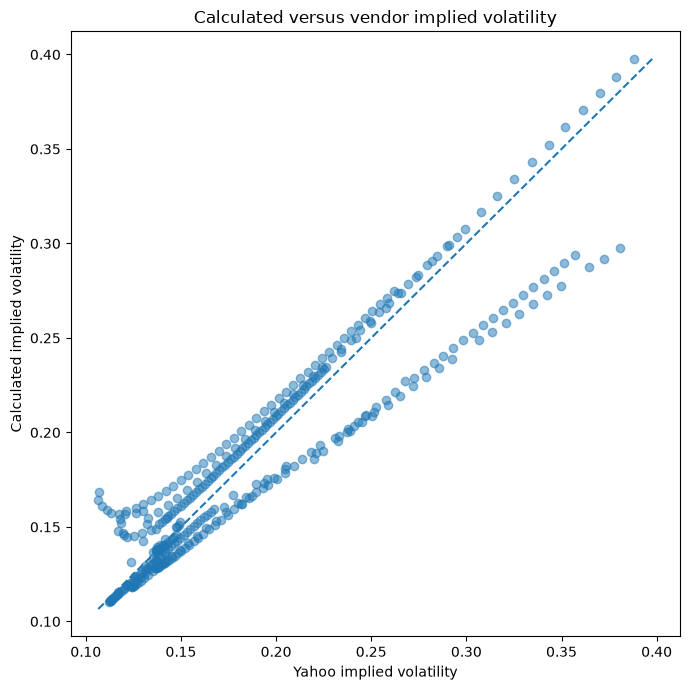

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    successful_quotes["impliedVolatility"],
    successful_quotes["model_implied_volatility"],
    alpha=0.5,
)

minimum = min(
    successful_quotes["impliedVolatility"].min(),
    successful_quotes["model_implied_volatility"].min(),
)

maximum = max(
    successful_quotes["impliedVolatility"].max(),
    successful_quotes["model_implied_volatility"].max(),
)

ax.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
)

ax.set_xlabel("Yahoo implied volatility")
ax.set_ylabel("Calculated implied volatility")
ax.set_title("Calculated versus vendor implied volatility")

fig.tight_layout()
plt.show()

# Forward-moneyness transformation

In [11]:
successful_quotes["forward_price"] = (
    successful_quotes["spot"]
    * np.exp(
        (
            successful_quotes["risk_free_rate"]
            - successful_quotes["dividend_yield"]
        )
        * successful_quotes["maturity"]
    )
)

successful_quotes["log_forward_moneyness"] = np.log(
    successful_quotes["strike"]
    / successful_quotes["forward_price"]
)

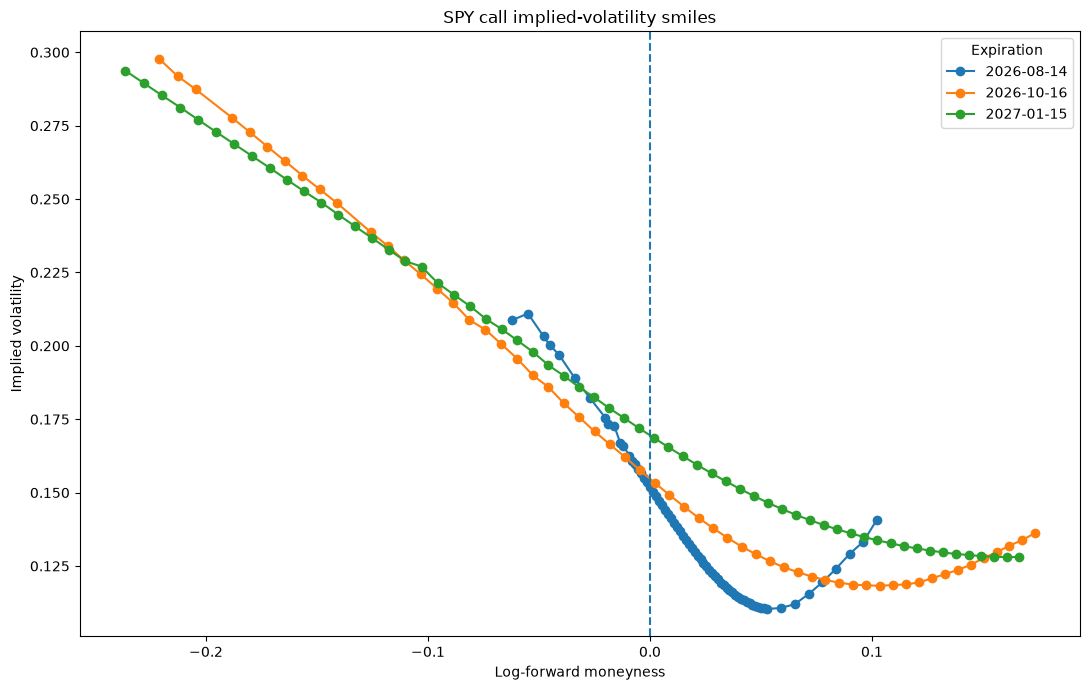

In [12]:
call_quotes = successful_quotes.loc[
    successful_quotes["option_type"] == "call"
].copy()

fig, ax = plt.subplots(figsize=(11, 7))

for expiration, expiry_quotes in call_quotes.groupby(
    "expiration"
):
    expiry_quotes = expiry_quotes.sort_values(
        "log_forward_moneyness"
    )

    ax.plot(
        expiry_quotes["log_forward_moneyness"],
        expiry_quotes["model_implied_volatility"],
        marker="o",
        label=str(expiration.date()),
    )

ax.axvline(0.0, linestyle="--")
ax.set_xlabel("Log-forward moneyness")
ax.set_ylabel("Implied volatility")
ax.set_title("SPY call implied-volatility smiles")
ax.legend(title="Expiration")

fig.tight_layout()
plt.show()

In [13]:
successful_quotes["is_otm"] = np.where(
    successful_quotes["option_type"] == "call",
    successful_quotes["strike"]
    >= successful_quotes["forward_price"],
    successful_quotes["strike"]
    <= successful_quotes["forward_price"],
)

otm_quotes = successful_quotes.loc[
    successful_quotes["is_otm"]
].copy()

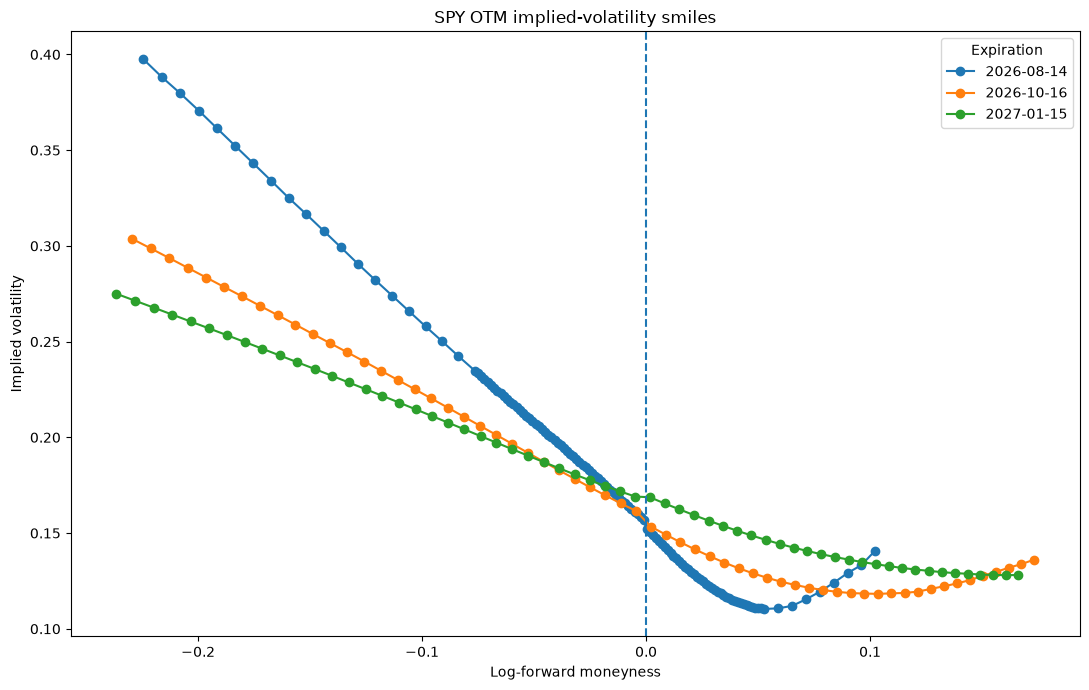

In [14]:
fig, ax = plt.subplots(figsize=(11, 7))

for expiration, expiry_quotes in otm_quotes.groupby(
    "expiration"
):
    expiry_quotes = expiry_quotes.sort_values(
        "log_forward_moneyness"
    )

    ax.plot(
        expiry_quotes["log_forward_moneyness"],
        expiry_quotes["model_implied_volatility"],
        marker="o",
        label=str(expiration.date()),
    )

ax.axvline(0.0, linestyle="--")
ax.set_xlabel("Log-forward moneyness")
ax.set_ylabel("Implied volatility")
ax.set_title("SPY OTM implied-volatility smiles")
ax.legend(title="Expiration")

fig.tight_layout()
plt.show()

# Put-call parity analysis

In [15]:
calls = filtered_quotes.loc[
    filtered_quotes["option_type"] == "call",
    [
        "expiration",
        "strike",
        "maturity",
        "spot",
        "mid_price",
        "spread",
    ],
].rename(
    columns={
        "mid_price": "call_mid",
        "spread": "call_spread",
    }
)

puts = filtered_quotes.loc[
    filtered_quotes["option_type"] == "put",
    [
        "expiration",
        "strike",
        "mid_price",
        "spread",
    ],
].rename(
    columns={
        "mid_price": "put_mid",
        "spread": "put_spread",
    }
)

parity = calls.merge(
    puts,
    on=["expiration", "strike"],
    how="inner",
)

# calculate parity error

parity["theoretical_call_minus_put"] = (
    parity["spot"]
    * np.exp(
        -DIVIDEND_YIELD * parity["maturity"]
    )
    - parity["strike"]
    * np.exp(
        -RISK_FREE_RATE * parity["maturity"]
    )
)

parity["observed_call_minus_put"] = (
    parity["call_mid"] - parity["put_mid"]
)

parity["parity_error"] = (
    parity["observed_call_minus_put"]
    - parity["theoretical_call_minus_put"]
)

parity["combined_half_spread"] = (
    parity["call_spread"]
    + parity["put_spread"]
) / 2.0

parity["outside_combined_spread"] = (
    parity["parity_error"].abs()
    > parity["combined_half_spread"]
)

# summarise 

parity_summary = (
    parity.groupby("expiration")
    .agg(
        matched_pairs=("strike", "size"),
        median_absolute_error=(
            "parity_error",
            lambda values: values.abs().median(),
        ),
        maximum_absolute_error=(
            "parity_error",
            lambda values: values.abs().max(),
        ),
        proportion_outside_spread=(
            "outside_combined_spread",
            "mean",
        ),
    )
    .reset_index()
)

parity_summary

,expiration,matched_pairs,median_absolute_error,maximum_absolute_error,proportion_outside_spread
0,2026-08-14,50,0.369326,1.882281,0.320000
1,2026-10-16,39,0.171296,3.380532,0.230769
2,2027-01-15,46,1.658747,4.919979,0.804348


# Vendor comparison branches investigation

In [16]:
vendor_comparison_by_group = (
    successful_quotes
    .groupby(["expiration", "option_type"])
    .agg(
        quotes=("vendor_iv_difference", "size"),
        mean_difference=("vendor_iv_difference", "mean"),
        median_absolute_difference=(
            "vendor_iv_difference",
            lambda values: values.abs().median(),
        ),
        rmse=(
            "vendor_iv_difference",
            lambda values: np.sqrt(np.mean(values**2)),
        ),
    )
    .reset_index()
)

vendor_comparison_by_group

,expiration,option_type,quotes,mean_difference,median_absolute_difference,rmse
0,2026-08-14,call,68,-0.008228,0.004065,0.012986
1,2026-08-14,put,105,0.007820,0.008758,0.008948
2,2026-10-16,call,57,-0.027412,0.014834,0.036608
3,2026-10-16,put,42,0.014853,0.012247,0.016351
4,2027-01-15,call,60,-0.029554,0.025278,0.034430
5,2027-01-15,put,46,0.024475,0.019723,0.027359


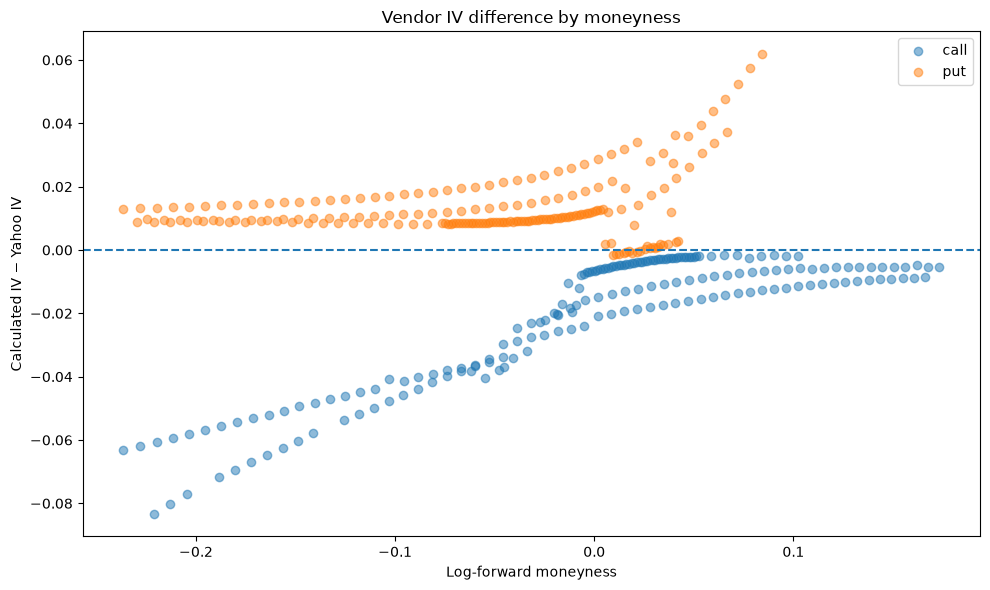

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

for option_type, group in successful_quotes.groupby("option_type"):
    ax.scatter(
        group["log_forward_moneyness"],
        group["vendor_iv_difference"],
        alpha=0.5,
        label=option_type,
    )

ax.axhline(0.0, linestyle="--")
ax.set_xlabel("Log-forward moneyness")
ax.set_ylabel("Calculated IV − Yahoo IV")
ax.set_title("Vendor IV difference by moneyness")
ax.legend()

fig.tight_layout()
plt.show()

The vendor comparison separates systematically by option type. Calculated call
implied volatilities are generally below Yahoo's values, while calculated put
implied volatilities are generally above them. The difference becomes larger at
longer maturities. This is unlikely to be random numerical error and may reflect
differences in exercise-style treatment, dividend assumptions, price inputs or
the vendor's calibration methodology.

# Results summary

In [18]:
results_summary = pd.Series(
    {
        "raw_quotes": len(raw_quotes),
        "filtered_quotes": len(filtered_quotes),
        "filter_retention_rate": (
            len(filtered_quotes) / len(raw_quotes)
        ),
        "successful_iv_calibrations": (
            calibrated_quotes["iv_converged"].sum()
        ),
        "iv_success_rate": (
            calibrated_quotes["iv_converged"].mean()
        ),
        "expirations_analysed": (
            successful_quotes["expiration"].nunique()
        ),
        "median_relative_spread": (
            filtered_quotes["relative_spread"].median()
        ),
        "median_vendor_iv_difference": (
            successful_quotes["vendor_iv_difference"].median()
        ),
        "matched_put_call_pairs": len(parity),
        "median_absolute_parity_error": (
            parity["parity_error"].abs().median()
        ),
    }
)

results_summary

raw_quotes                      892.000000
filtered_quotes                 378.000000
filter_retention_rate             0.423767
successful_iv_calibrations      378.000000
iv_success_rate                   1.000000
expirations_analysed              3.000000
median_relative_spread            0.013396
median_vendor_iv_difference      -0.000985
matched_put_call_pairs          135.000000
median_absolute_parity_error      0.607573
dtype: float64

# Conclusion

- 378 of 378 filtered quotes calibrated successfully;
- calculated IVs broadly agreed with Yahoo’s values;
- implied volatility varied systematically across strike;
- downside skew was strongest at the shortest maturity;
- a constant volatility could not explain the complete price cross-section.